Types of graphs to test (each in sparse and dense variants where applicable):
Simple graph
Multigraph
Pseudograph
Directed graph
Directed Multigraph
Complete graph
Wheels
Bipartite graph
Regular graph
Planar graph (grid-based)
Trees
Cyclic graph
Weighted graph

Edge counts to sweep (easy to extend): 10, 50, 100, 200, 500, 1000

Notes:
- The main size parameter is the number of vertices n.
- Edge counts are derived per graph family and density (sparse or dense).
- Each size is tested multiple times and results are averaged.

In [21]:
"""
Fully Dynamic Depth-First Search in Directed Graphs
Yang et al. (PVLDB 2019) – fully optimised Python implementation.

Performance fixes applied
-------------------------
1. O(n²) build_tree: _connect_to_root used a linear-scan membership check on
   the VROOT out-neighbour list (which grows to n entries).  Fixed by keeping
   a companion set _out_set[v] for O(1) membership; only lists are used during
   DFS traversal (set not iterated in hot paths).

2. Per-edge _ensure calls in build_tree: the old code called _ensure(u,v) for
   every edge, causing O(m) repeated dict look-ups and O(n) root-connection
   checks.  Fixed: collect unique vertices once, batch-allocate, then add edges
   in a single O(m) pass.

3. Duplicate init code in _rebuild_dfs: the old code contained dead code
   (two separate stacks created) and called ts[0] through a list instead of
   a plain int.  Fixed: single clean iterative DFS with a local `ts` counter.

4. _in_ci / _contains_ci called as methods in the inner loop.  Fixed: inlined
   into each call site using local variable aliases.

5. Tuple replacement on call stack: `call_stack[-1] = (u, ci+1)` creates a
   new tuple every iteration.  Fixed: store frames as a parallel list so we
   can update in-place with `ci_stack[-1] = new_ci`.

6. _del_hybrid_dfs / _ins_hybrid_dfs: reads of self._disc, self._fin etc.
   inside the tight loop go through attribute look-up every iteration.
   Fixed: all hot arrays aliased to local variables before each loop.
"""

from __future__ import annotations

VROOT = 0   # virtual root γ is always internal vertex 0


class DynamicDFSTree:
    """
    Maintains a DFS-Tree for a directed graph under edge insertions/deletions.
    Public vertex labels can be any hashable; they are mapped to dense ints
    internally (VROOT=0 reserved).
    """

    # ------------------------------------------------------------------
    # Construction
    # ------------------------------------------------------------------

    def __init__(self) -> None:
        self._to_id:   dict = {}    # label  → internal int
        self._to_lbl:  list = []    # int    → label
        self._n:       int  = 0     # next free id

        # adjacency  (indexed by internal id)
        self._out:     list[list[int]] = []   # out-neighbours (list for DFS order)
        self._in:      list[list[int]] = []   # in-neighbours
        self._out_set: list[set]       = []   # O(1) membership for out-edges

        # DFS-Tree state
        self._parent:   list[int]       = []
        self._children: list[list[int]] = []
        self._disc:     list[int]       = []   # discovery  timestamp
        self._fin:      list[int]       = []   # finish     timestamp
        self._depth:    list[int]       = []   # tree depth (for LCA)

        # scratch for constrained DFS
        self._ci_left:  int = 0
        self._ci_right: int = 0
        self._ts:       int = 0

        self._alloc_vertex("__vroot__")        # id 0

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def add_vertex(self, label) -> None:
        vid = self._alloc_vertex(label)
        self._connect_to_root(vid)
        self._rebuild_dfs()

    def insert_edge(self, s_lbl, t_lbl) -> None:
        self._ensure(s_lbl); self._ensure(t_lbl)
        s, t = self._to_id[s_lbl], self._to_id[t_lbl]
        if t in self._out_set[s]:
            return
        self._out[s].append(t);  self._out_set[s].add(t)
        self._in[t].append(s)
        self._dfs_insert_star(s, t)

    def delete_edge(self, s_lbl, t_lbl) -> None:
        s, t = self._to_id[s_lbl], self._to_id[t_lbl]
        if t not in self._out_set[s]:
            raise ValueError(f"Edge ({s_lbl}, {t_lbl}) does not exist.")
        self._out[s].remove(t);  self._out_set[s].discard(t)
        self._in[t].remove(s)
        self._dfs_delete_star(s, t)

    def get_parent(self, label):
        p = self._parent[self._to_id[label]]
        return None if p <= VROOT else self._to_lbl[p]

    def get_children(self, label) -> list:
        return [self._to_lbl[c] for c in self._children[self._to_id[label]]]

    def get_depth(self, label) -> int:
        return self._depth[self._to_id[label]]

    def validate(self) -> bool:
        """O(n+m) validity check: no forward-cross edge may exist."""
        fin  = self._fin
        disc = self._disc
        for s, nbs in enumerate(self._out):
            if s == VROOT:
                continue
            for t in nbs:
                if fin[s] < disc[t]:    # forward-cross
                    return False
        return True

    def print_tree(self, vid: int = VROOT, indent: int = 0) -> None:
        lbl = "γ" if vid == VROOT else str(self._to_lbl[vid])
        print("  " * indent + f"{lbl} [{self._disc[vid]}, {self._fin[vid]}]")
        for c in self._children[vid]:
            self.print_tree(c, indent + 1)

    # ------------------------------------------------------------------
    # Vertex allocation helpers
    # ------------------------------------------------------------------

    def _alloc_vertex(self, label) -> int:
        vid = self._n;  self._n += 1
        self._to_id[label] = vid
        self._to_lbl.append(label)
        self._out.append([]);         self._out_set.append(set())
        self._in.append([])
        self._parent.append(-1);      self._children.append([])
        self._disc.append(0);         self._fin.append(0)
        self._depth.append(0)
        return vid

    def _bulk_alloc(self, labels) -> None:
        """Allocate many vertices at once – avoids per-vertex append overhead."""
        start = self._n
        n_new = len(labels)
        self._n += n_new
        for i, label in enumerate(labels):
            self._to_id[label] = start + i
        self._to_lbl.extend(labels)
        self._out.extend([] for _ in range(n_new))
        self._out_set.extend(set() for _ in range(n_new))
        self._in.extend([] for _ in range(n_new))
        self._parent.extend([-1] * n_new)
        self._children.extend([] for _ in range(n_new))
        self._disc.extend([0] * n_new)
        self._fin.extend([0] * n_new)
        self._depth.extend([0] * n_new)

    def _ensure(self, label) -> None:
        if label not in self._to_id:
            vid = self._alloc_vertex(label)
            self._connect_to_root(vid)

    def _connect_to_root(self, vid: int) -> None:
        """Add VROOT → vid if not already present.  O(1) via _out_set."""
        if vid not in self._out_set[VROOT]:
            self._out[VROOT].append(vid);  self._out_set[VROOT].add(vid)
            self._in[vid].append(VROOT)

    # ------------------------------------------------------------------
    # Full DFS rebuild  (iterative, O(n+m))
    # ------------------------------------------------------------------

    def _rebuild_dfs(self) -> None:
        n        = self._n
        out      = self._out
        parent   = self._parent
        children = self._children
        disc     = self._disc
        fin      = self._fin
        depth    = self._depth

        # Reset tree state  (slices are faster than a Python loop)
        for v in range(n):
            children[v] = []
            parent[v]   = -1
            disc[v]     = 0
            fin[v]      = 0
            depth[v]    = 0

        visited = bytearray(n)   # bytearray: ~4× faster index access than list[bool]
        ts      = 1

        # Iterative DFS: parallel vertex-stack and child-index stack
        # avoids tuple creation per frame (fix #5)
        v_stack  = [VROOT]
        ci_stack = [0]
        visited[VROOT] = 1
        disc[VROOT]    = ts;  ts += 1

        while v_stack:
            u  = v_stack[-1]
            ci = ci_stack[-1]
            nbs = out[u]
            if ci < len(nbs):
                ci_stack[-1] = ci + 1
                v = nbs[ci]
                if not visited[v]:
                    visited[v]   = 1
                    disc[v]      = ts;  ts += 1
                    parent[v]    = u
                    depth[v]     = depth[u] + 1
                    children[u].append(v)
                    v_stack.append(v)
                    ci_stack.append(0)
            else:
                v_stack.pop();  ci_stack.pop()
                fin[u] = ts;  ts += 1

    # ------------------------------------------------------------------
    # Helpers  (inlined at call sites in hot loops for speed)
    # ------------------------------------------------------------------

    def _is_tree_edge(self, s: int, t: int) -> bool:
        return self._parent[t] == s

    def _lca(self, u: int, v: int) -> int:
        disc = self._disc
        par  = self._parent
        a, b = u, v
        while a != b:
            if disc[a] > disc[b]:
                a = par[a]
            else:
                b = par[b]
        return a

    def _subtree_ids(self, root: int) -> list[int]:
        result   = []
        stack    = [root]
        children = self._children
        while stack:
            u = stack.pop()
            result.append(u)
            stack.extend(children[u])
        return result

    # ------------------------------------------------------------------
    # Algorithm 6 + 7  DFS-Insert*  (iterative InsHybrid-DFS)
    # ------------------------------------------------------------------

    def _dfs_insert_star(self, s: int, t: int) -> None:
        fin  = self._fin
        disc = self._disc

        # Only forward-cross edges break the tree
        if not (fin[s] < disc[t]):
            return

        self._ci_left  = fin[s]
        self._ci_right = fin[t]

        # Reassign t as last child of s
        old_p = self._parent[t]
        if old_p >= 0:
            ch = self._children[old_p]
            if t in ch:
                ch.remove(t)
        self._children[s].append(t)
        self._parent[t] = s
        self._depth[t]  = self._depth[s] + 1

        r = self._lca(s, t)
        self._ts = self._ci_left

        visited = bytearray(self._n)
        self._ins_hybrid_dfs(r, t, visited)

    def _ins_hybrid_dfs(self, root: int, t: int, visited: bytearray) -> None:
        """Iterative InsHybrid-DFS (Algorithm 7)."""
        # Local aliases — avoids repeated attribute look-up in the hot loop
        disc     = self._disc
        fin      = self._fin
        children = self._children
        out      = self._out
        parent   = self._parent
        depth    = self._depth

        ci_left  = self._ci_left

        v_stack  = [root]
        ci_stack = [0]
        visited[root] = 1
        if disc[root] >= ci_left:
            disc[root] = self._ts;  self._ts += 1

        # Precompute subtree bounds for t once
        t_disc = disc[t];  t_fin = fin[t]

        while v_stack:
            u  = v_stack[-1]
            ci = ci_stack[-1]

            # Is u in subtree of t?  Use interval check (inlined _is_in_subtree)
            in_subtree_t = (t_disc <= disc[u] <= t_fin)

            if in_subtree_t:
                # --- Graph search ---
                nbs = out[u]
                advanced = False
                while ci < len(nbs):
                    v = nbs[ci];  ci += 1
                    if visited[v]:
                        continue
                    # Inlined _in_ci: (ci_left <= disc[v] <= ci_right) or same for fin
                    ci_r = self._ci_right
                    dv   = disc[v];  fv = fin[v]
                    in_ci = (ci_left <= dv <= ci_r) or (ci_left <= fv <= ci_r)
                    if not in_ci:
                        continue
                    # Inlined _contains_ci: disc[v] <= ci_left and fin[v] >= ci_right
                    if dv <= ci_left and fv >= ci_r:
                        continue
                    # Expand CI right if needed (Lemma 8)
                    if fv > self._ci_right:
                        self._ci_right = fv
                    # Re-parent v under u
                    old_p = parent[v]
                    if old_p >= 0:
                        ch = children[old_p]
                        if v in ch:
                            ch.remove(v)
                    children[u].append(v)
                    parent[v] = u
                    depth[v]  = depth[u] + 1
                    ci_stack[-1] = ci
                    visited[v]   = 1
                    if disc[v] >= ci_left:
                        disc[v] = self._ts;  self._ts += 1
                    v_stack.append(v);  ci_stack.append(0)
                    advanced = True
                    break
                if not advanced:
                    v_stack.pop();  ci_stack.pop()
                    if fin[u] <= self._ci_right:
                        fin[u] = self._ts;  self._ts += 1
                    # Update t's cached interval after its subtree is processed
                    t_disc = disc[t];  t_fin = fin[t]
            else:
                # --- Tree search ---
                ch = children[u]
                advanced = False
                while ci < len(ch):
                    v = ch[ci];  ci += 1
                    if visited[v]:
                        continue
                    ci_r = self._ci_right
                    dv   = disc[v];  fv = fin[v]
                    in_ci = (ci_left <= dv <= ci_r) or (ci_left <= fv <= ci_r)
                    if not in_ci:
                        continue
                    ci_stack[-1] = ci
                    visited[v]   = 1
                    if dv >= ci_left:
                        disc[v] = self._ts;  self._ts += 1
                    v_stack.append(v);  ci_stack.append(0)
                    advanced = True
                    break
                if not advanced:
                    v_stack.pop();  ci_stack.pop()
                    if fin[u] <= self._ci_right:
                        fin[u] = self._ts;  self._ts += 1

    # ------------------------------------------------------------------
    # Algorithm 8-10  DFS-Delete*  (iterative DelHybrid-DFS)
    # ------------------------------------------------------------------

    def _dfs_delete_star(self, s: int, t: int) -> None:
        if not self._is_tree_edge(s, t):
            return

        ch = self._children[s]
        if t in ch:
            ch.remove(t)
        self._parent[t] = -1

        vc_set = set(self._subtree_ids(t))

        self._ci_left  = self._disc[t]
        self._ci_right = 10 ** 18    # effectively +∞
        self._ts       = self._ci_left

        # Temporary virtual-root edge
        if t not in self._out_set[VROOT]:
            self._out[VROOT].append(t);  self._out_set[VROOT].add(t)
            self._in[t].append(VROOT)

        self._vc    = vc_set
        self._del_r = -1
        self._locate_next_trigger(s)

        visited = bytearray(self._n)
        while self._vc:
            if self._del_r < 0:
                break
            self._del_hybrid_dfs(self._del_r, visited)

        # Remove temporary edge
        if t in self._out_set[VROOT]:
            self._out[VROOT].remove(t);  self._out_set[VROOT].discard(t)
            self._in[t].remove(VROOT)

    # ---- earliest-visit helpers ------------------------------------------

    def _earliest_visit_time(self, u: int):
        disc    = self._disc
        fin     = self._fin
        ci_left = self._ci_left
        vc      = self._vc
        best_ev = 10 ** 18
        best_pp = VROOT
        for p in self._in[u]:
            if p in vc:
                continue
            ev = disc[p] + 1
            for ch in self._children[p]:
                if disc[ch] < ci_left:
                    fch = fin[ch] + 1
                    if fch > ev:
                        ev = fch
            if ev < best_ev:
                best_ev = ev
                best_pp = p
        return best_pp, best_ev

    def _locate_next_trigger(self, deleted_src: int) -> None:
        vc = self._vc
        if not vc:
            return
        best_vid, best_ev, best_pp = -1, 10 ** 18, VROOT
        for vid in vc:
            pp, ev = self._earliest_visit_time(vid)
            if ev < best_ev:
                best_ev, best_vid, best_pp = ev, vid, pp
        if best_vid < 0:
            return

        trigger = best_vid
        old_p   = self._parent[trigger]
        if old_p >= 0:
            ch = self._children[old_p]
            if trigger in ch:
                ch.remove(trigger)

        self._parent[trigger] = best_pp
        self._depth[trigger]  = self._depth[best_pp] + 1
        ci_left   = self._ci_left
        disc      = self._disc
        insert_idx = 0
        for i, ch in enumerate(self._children[best_pp]):
            if disc[ch] < ci_left:
                insert_idx = i + 1
        self._children[best_pp].insert(insert_idx, trigger)

        if self._del_r < 0:
            self._del_r = self._lca(deleted_src, best_pp)
        else:
            self._del_r = self._lca(self._del_r, best_pp)

    def _del_hybrid_dfs(self, root: int, visited: bytearray) -> None:
        """Iterative DelHybrid-DFS (Algorithm 10) with local-alias hot loop."""
        vc       = self._vc
        disc     = self._disc
        fin      = self._fin
        children = self._children
        out      = self._out
        parent   = self._parent
        depth    = self._depth
        ci_left  = self._ci_left
        INF      = 10 ** 18

        v_stack  = [root]
        ci_stack = [0]
        visited[root] = 1
        if disc[root] >= ci_left or root in vc:
            disc[root] = self._ts;  self._ts += 1

        while v_stack:
            u  = v_stack[-1]
            ci = ci_stack[-1]

            if u in vc:
                # Graph search over Vc neighbours only
                nbs = out[u]
                advanced = False
                while ci < len(nbs):
                    v = nbs[ci];  ci += 1
                    if v not in vc or visited[v]:
                        continue
                    parent[v] = u
                    depth[v]  = depth[u] + 1
                    children[u].append(v)
                    ci_stack[-1] = ci
                    visited[v]   = 1
                    disc[v]      = self._ts;  self._ts += 1
                    v_stack.append(v);  ci_stack.append(0)
                    advanced = True
                    break
                if not advanced:
                    vc.discard(u)
                    v_stack.pop();  ci_stack.pop()
                    ci_r = self._ci_right
                    if ci_r == INF or fin[u] <= ci_r:
                        fin[u] = self._ts;  self._ts += 1
                    self._ci_left = ci_left = self._ts
                    if not vc:
                        self._ci_right = self._ts - 1
            else:
                # Tree search
                ch = children[u]
                advanced = False
                while ci < len(ch):
                    v = ch[ci];  ci += 1
                    if visited[v]:
                        continue
                    dv = disc[v];  fv = fin[v]
                    in_range = (dv >= ci_left or fv >= ci_left or v in vc)
                    if not in_range:
                        continue
                    ci_stack[-1] = ci
                    visited[v]   = 1
                    if dv >= ci_left or v in vc:
                        disc[v] = self._ts;  self._ts += 1
                    v_stack.append(v);  ci_stack.append(0)
                    advanced = True
                    break
                if not advanced:
                    v_stack.pop();  ci_stack.pop()
                    ci_r = self._ci_right
                    if ci_r == INF or fin[u] <= ci_r:
                        fin[u] = self._ts;  self._ts += 1
                    self._ci_left = ci_left = self._ts
                    if vc:
                        self._locate_next_trigger(u)


# ---------------------------------------------------------------------------
# Convenience constructor  (O(n + m), no O(n²) membership checks)
# ---------------------------------------------------------------------------

def build_tree(edges: list[tuple]) -> DynamicDFSTree:
    """
    Build a DynamicDFSTree from a list of (src, dst) directed edges.

    Optimised construction
    ----------------------
    1. Collect unique vertices in one O(m) pass.
    2. _bulk_alloc: extend all flat arrays in one call per array — avoids
       the Python-level loop overhead of N individual appends.
    3. Connect all vertices to VROOT in a single list-extend + set-update.
    4. Add edges in one O(m) pass with O(1) set membership checks.
    5. Single _rebuild_dfs call — O(n + m).
    """
    tree = DynamicDFSTree()

    # Pass 1: unique vertices
    vset = set()
    for s, t in edges:
        vset.add(s);  vset.add(t)
    new_verts = [v for v in vset if v not in tree._to_id]

    # Pass 2: bulk-allocate
    tree._bulk_alloc(new_verts)

    # Pass 3: connect all new vertices to VROOT at once
    to_id    = tree._to_id
    new_vids = [to_id[v] for v in new_verts]
    tree._out[VROOT].extend(new_vids)
    tree._out_set[VROOT].update(new_vids)
    in_ = tree._in
    for vid in new_vids:
        in_[vid].append(VROOT)

    # Pass 4: add edges
    out     = tree._out
    out_set = tree._out_set
    for s, t in edges:
        sid, tid = to_id[s], to_id[t]
        if tid not in out_set[sid]:
            out[sid].append(tid);  out_set[sid].add(tid)
            in_[tid].append(sid)

    # Pass 5: single DFS
    tree._rebuild_dfs()
    return tree


# ---------------------------------------------------------------------------
# Smoke test
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    edges = [
        ("v0","v1"),("v0","v10"),("v1","v2"),("v1","v4"),("v2","v0"),
        ("v3","v10"),("v4","v3"),("v4","v5"),("v5","v6"),("v6","v7"),
        ("v6","v11"),("v7","v2"),("v8","v9"),("v8","v10"),("v9","v13"),
        ("v10","v12"),("v11","v8"),("v11","v14"),("v12","v15"),
        ("v13","v14"),("v14","v16"),("v15","v16"),("v15","v17"),
        ("v16","v18"),("v17","v18"),("v18","v13"),
    ]
    print("Building initial DFS-Tree …")
    tree = build_tree(edges)
    tree.print_tree()
    assert tree.validate(), "INVALID after build!"
    print("Valid ✓\n")

    print("Inserting (v8, v13) …")
    tree.insert_edge("v8", "v13")
    assert tree.validate(), "INVALID after insert!"
    print("Valid ✓\n")

    print("Deleting (v5, v6) …")
    tree.delete_edge("v5", "v6")
    assert tree.validate(), "INVALID after delete!"
    print("Valid ✓")

Building initial DFS-Tree …
γ [1, 40]
  v3 [2, 19]
    v10 [3, 18]
      v12 [4, 17]
        v15 [5, 16]
          v16 [6, 13]
            v18 [7, 12]
              v13 [8, 11]
                v14 [9, 10]
          v17 [14, 15]
  v1 [20, 39]
    v2 [21, 24]
      v0 [22, 23]
    v4 [25, 38]
      v5 [26, 37]
        v6 [27, 36]
          v7 [28, 29]
          v11 [30, 35]
            v8 [31, 34]
              v9 [32, 33]
Valid ✓

Inserting (v8, v13) …
Valid ✓

Deleting (v5, v6) …
Valid ✓


In [22]:
"""
Optimal Algebraic Breadth-First Search for Sparse Graphs
Implementation of Burkhardt (arXiv:1906.03113v4, 2021) – optimised for performance.

Key performance changes vs the original implementation
-------------------------------------------------------
* Semiring dispatch eliminated: the hot loop uses direct boolean/int operations
  instead of static-method calls through a semiring class. The semiring
  abstraction is kept for the generic Algorithm 1, but Algorithm 2 (the one
  benchmarked) uses inlined ops.
* Algorithm 1 inlines boolean OR/AND instead of going through sr.add/sr.mul.
* CSRMatrix builds from a plain adjacency list with no intermediate set
  conversions in the hot path.
* The BFS queue (L array) is a pre-allocated list with integer start/end
  pointers — no deque overhead, no Python list growth/copy.
* T (visited) is a bytearray for O(1) integer indexing without boxing.
* The output level dict is only constructed on request; internally BFS just
  fills the L array and a level-pointer array.
"""

from __future__ import annotations
import threading
from collections import defaultdict
from typing import Any


# ---------------------------------------------------------------------------
# Semiring  (kept for Algorithm 1 generality; not used in hot paths)
# ---------------------------------------------------------------------------

class BooleanSemiring:
    add  = staticmethod(lambda a, b: a or b)
    mul  = staticmethod(lambda a, b: a and b)
    zero = False
    one  = True

class ArithmeticSemiring:
    add  = staticmethod(lambda a, b: a + b)
    mul  = staticmethod(lambda a, b: a * b)
    zero = 0
    one  = 1


# ---------------------------------------------------------------------------
# CSR matrix
# ---------------------------------------------------------------------------

class CSRMatrix:
    """
    Compressed Sparse Row adjacency matrix.
    Arrays nz, col, row mirror the paper's notation exactly.
    """
    __slots__ = ("n", "nz", "col", "row", "directed")

    def __init__(self, n: int, edges: list[tuple], directed: bool = False):
        self.n        = n
        self.directed = directed

        adj: list[list[int]] = [[] for _ in range(n)]
        for u, v in edges:
            adj[u].append(v)
            if not directed and u != v:
                adj[v].append(u)
        for i in range(n):
            adj[i] = sorted(set(adj[i]))

        nz_list:  list[bool] = []
        col_list: list[int]  = []
        row_arr:  list[int]  = [0] * (n + 1)
        for i in range(n):
            row_arr[i] = len(col_list)
            for j in adj[i]:
                col_list.append(j)
                nz_list.append(True)
        row_arr[n] = len(col_list)

        self.nz  = nz_list
        self.col = col_list
        self.row = row_arr

    @property
    def m(self) -> int:
        return len(self.nz)


# ---------------------------------------------------------------------------
# Algorithm 1 – General submatrix BFS  (Section 8)
# ---------------------------------------------------------------------------

def bfs_algorithm1(
    adj: dict[int, list[int]],
    n:   int,
    source: int,
    semiring=None,   # ignored; boolean ops inlined
) -> dict[int, int]:
    """
    General formulation: x_{k+1} = A[V_{k+1}, V_k] x_k  (Theorem 1).

    Optimisations vs original:
    - V tracked as a bytearray rather than a Python set (O(1) array index,
      no hashing cost).
    - Frontier as a plain list; next frontier accumulated in a list.
    - Boolean AND/OR inlined; no semiring method dispatch.
    - V_prime updated in-place via the visited array (short-circuit, line 6
      of Algorithm 1 in the paper).
    """
    visited   = bytearray(n)
    level_arr = [-1] * n
    frontier  = [source]
    visited[source]   = 1
    level_arr[source] = 0
    k = 1

    while frontier:
        nxt = []
        for j in frontier:
            nb = adj.get(j)
            if nb:
                for i in nb:
                    if not visited[i]:
                        visited[i]   = 1
                        level_arr[i] = k
                        nxt.append(i)
        frontier = nxt
        k += 1

    return {i: level_arr[i] for i in range(n) if level_arr[i] >= 0}


# ---------------------------------------------------------------------------
# Algorithm 2 – Sequential CSR BFS  (Section 9)  ← OPTIMISED
# ---------------------------------------------------------------------------

def bfs_algorithm2(
    csr:    CSRMatrix,
    source: int,
    semiring=None,   # ignored; boolean ops inlined for speed
) -> tuple[dict[int, int], int]:
    """
    Optimal sequential CSR BFS.
    Returns (level_dict, algebraic_op_count).

    Hot-path optimisations
    ----------------------
    * visited array is a bytearray (C-level integer array, ~8x cheaper than
      a Python list of bools for index access).
    * Inner loop variables are aliased to locals before the loop to avoid
      repeated LOAD_ATTR bytecodes.
    * Semiring mul/add inlined as boolean AND/OR (always True for unweighted).
    * Level array (L) pre-allocated to full size n to avoid any reallocation.
    """
    n   = csr.n
    col = csr.col
    row = csr.row
    ops = 0

    # Pre-allocate arrays
    L = [0] * n             # BFS queue (indices into vertex space)
    T = bytearray(n)        # visited: 0 = unvisited, 1 = visited (bytearray = fast)
    level_arr = [-1] * n    # BFS level per vertex

    # Initialise source
    T[source]         = 1
    L[0]              = source
    level_arr[source] = 0
    start, end, z     = 0, 1, 1
    k                 = 1

    while start < end:
        for qi in range(start, end):
            j       = L[qi]
            row_j   = row[j]
            row_j1  = row[j + 1]
            for idx in range(row_j, row_j1):
                i = col[idx]
                if not T[i]:
                    # y[i] ← y[i] OR (x[j] AND A[i,j])  → True (inlined)
                    ops += 2
                    T[i]         = 1
                    L[z]         = i
                    level_arr[i] = k
                    z           += 1
            T[j] = 1   # mark source-frontier vertex done

        start = end
        end   = z
        k    += 1

    # Build output dict only for reachable vertices
    level = {L[i]: level_arr[L[i]] for i in range(z)}
    return level, ops


# ---------------------------------------------------------------------------
# Algorithm 3 – Parallel CSR BFS  (Section 10)
# ---------------------------------------------------------------------------

def bfs_algorithm3(
    csr:         CSRMatrix,
    source:      int,
    num_threads: int = 4,
    semiring=None,
) -> dict[int, int]:
    """
    Work-optimal parallel CSR BFS.
    Uses Python threads; synchronisation mirrors the paper's PRAM description.
    """
    n   = csr.n
    col = csr.col
    row = csr.row

    L         = [0] * n
    T         = bytearray(n)
    P         = [-1] * n
    level_arr = [-1] * n

    T[source]         = 1
    L[0]              = source
    level_arr[source] = 0
    start, end, z     = 0, 1, 1
    k                 = 1

    t_lock = threading.Lock()   # guards T and z writes

    while start < end:
        # Divide the current frontier [start, end) among threads
        level_size = end - start
        chunk      = max(1, level_size // num_threads)

        def process(l_start: int, l_end: int) -> None:
            """Process L[l_start .. l_end) — absolute indices into L."""
            nonlocal z
            for qi in range(l_start, l_end):
                j = L[qi]
                for idx in range(row[j], row[j + 1]):
                    i = col[idx]
                    if not T[i]:
                        with t_lock:
                            if not T[i]:   # double-checked locking
                                T[i]         = 1
                                L[z]         = i
                                level_arr[i] = k
                                z           += 1
                T[j] = 1

        threads = []
        for tid in range(num_threads):
            l_start = start + tid * chunk
            l_end   = l_start + chunk if tid < num_threads - 1 else end
            t       = threading.Thread(target=process, args=(l_start, l_end))
            threads.append(t)
            t.start()
        for t in threads:
            t.join()

        start = end
        end   = z
        k    += 1

    return {L[i]: level_arr[L[i]] for i in range(z)}


# ---------------------------------------------------------------------------
# Utility
# ---------------------------------------------------------------------------

def build_adj(n: int, edges: list[tuple], directed: bool = False) -> dict:
    adj: dict[int, list[int]] = defaultdict(list)
    for u, v in edges:
        adj[u].append(v)
        if not directed:
            adj[v].append(u)
    return {k: sorted(set(v)) for k, v in adj.items()}


# ---------------------------------------------------------------------------
# Smoke test
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Figure 1 from the paper (0-indexed)
    n_fig1    = 5
    edges_fig1 = [(0,3),(1,4),(2,3),(2,4),(3,0),(4,1)]
    source     = 1

    print("=== Figure 1 graph (path 2-5-3-4-1) ===")
    adj_fig1 = build_adj(n_fig1, edges_fig1)
    csr_fig1 = CSRMatrix(n_fig1, edges_fig1)

    lv1 = bfs_algorithm1(adj_fig1, n_fig1, source)
    lv2, ops = bfs_algorithm2(csr_fig1, source)
    lv3 = bfs_algorithm3(csr_fig1, source, num_threads=2)

    print("Alg1:", {k+1: v for k,v in lv1.items()})
    print("Alg2:", {k+1: v for k,v in lv2.items()}, f"  ops={ops} (expect {2*(n_fig1-1)})")
    print("Alg3:", {k+1: v for k,v in lv3.items()})
    assert lv1 == {v: lv2[v] for v in lv1}
    assert lv2 == {v: lv3[v] for v in lv2}
    print("✓ All three agree.\n")

    # Operation count comparison
    print("=== Op count vs SpMmSpV-BFS ===")
    def spmspv_ops(csr, src):
        visited = bytearray(csr.n); visited[src] = 1
        frontier = [src]; ops = 0
        while frontier:
            nxt = []
            for j in frontier:
                for idx in range(csr.row[j], csr.row[j+1]):
                    i = csr.col[idx]; ops += 2
                    if not visited[i]:
                        visited[i] = 1; nxt.append(i)
            frontier = nxt
        return ops

    for label, n_g, edges_g, src_g in [
        ("Figure-1 path", n_fig1, edges_fig1, source),
    ]:
        csr_g      = CSRMatrix(n_g, edges_g)
        _, our_ops = bfs_algorithm2(csr_g, src_g)
        sp_ops     = spmspv_ops(csr_g, src_g)
        print(f"{label}: Alg2={our_ops} ops, SpMmSpV={sp_ops} ops, "
              f"speedup={sp_ops/our_ops:.1f}x")

=== Figure 1 graph (path 2-5-3-4-1) ===
Alg1: {1: 4, 2: 0, 3: 2, 4: 3, 5: 1}
Alg2: {2: 0, 5: 1, 3: 2, 4: 3, 1: 4}   ops=8 (expect 8)
Alg3: {2: 0, 5: 1, 3: 2, 4: 3, 1: 4}
✓ All three agree.

=== Op count vs SpMmSpV-BFS ===
Figure-1 path: Alg2=8 ops, SpMmSpV=16 ops, speedup=2.0x


In [23]:
# Experiment setup
from __future__ import annotations

import math
import random
import time
from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Size sweep (easy to extend)
VERTEX_SIZES = [10, 50, 100, 200, 500, 1000]

# Trials per (graph type, density, size)
NUM_TRIALS = 3

# Densities
DENSITIES = ["sparse", "dense"]

In [24]:
# Graph generation helpers

@dataclass
class GraphInstance:
    n: int
    edges: List[Tuple[int, int]]
    directed: bool
    weighted: bool = False


def _max_edges_simple(n: int, directed: bool) -> int:
    if directed:
        return n * (n - 1)
    return n * (n - 1) // 2


def _edge_target(n: int, directed: bool, density: str, max_edges: int) -> int:
    if density == "sparse":
        return min(max_edges, max(1, 2 * n))
    # dense
    return min(max_edges, max(1, int(0.6 * max_edges)))


def _random_edges_simple(n: int, m: int, directed: bool) -> List[Tuple[int, int]]:
    edges = set()
    while len(edges) < m:
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        if directed:
            edges.add((u, v))
        else:
            a, b = (u, v) if u < v else (v, u)
            edges.add((a, b))
    return list(edges)


def _add_random_edges_existing(
    n: int,
    edges: List[Tuple[int, int]],
    directed: bool,
    target_m: int,
    ) -> List[Tuple[int, int]]:
    edge_set = set(edges)
    while len(edge_set) < target_m:
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        if directed:
            edge_set.add((u, v))
        else:
            a, b = (u, v) if u < v else (v, u)
            edge_set.add((a, b))
    return list(edge_set)


def _grid_edges(n: int) -> List[Tuple[int, int]]:
    side = max(2, int(math.sqrt(n)))
    rows = side
    cols = max(2, (n + rows - 1) // rows)
    total = rows * cols
    edges = []
    for r in range(rows):
        for c in range(cols):
            u = r * cols + c
            if u >= n:
                continue
            if c + 1 < cols and u + 1 < n:
                edges.append((u, u + 1))
            if r + 1 < rows:
                v = (r + 1) * cols + c
                if v < n:
                    edges.append((u, v))
    return edges


def _cycle_edges(n: int) -> List[Tuple[int, int]]:
    return [(i, (i + 1) % n) for i in range(n)]


def _tree_edges(n: int) -> List[Tuple[int, int]]:
    # Random tree via incremental attachment
    edges = []
    for v in range(1, n):
        p = random.randrange(v)
        edges.append((p, v))
    return edges


def _wheel_edges(n: int) -> List[Tuple[int, int]]:
    if n < 4:
        return _cycle_edges(n)
    hub = n - 1
    edges = []
    for i in range(n - 1):
        edges.append((i, (i + 1) % (n - 1)))
        edges.append((hub, i))
    return edges


def _bipartite_edges(n: int, m: int) -> List[Tuple[int, int]]:
    left = n // 2
    right = n - left
    edges = set()
    while len(edges) < m:
        u = random.randrange(left)
        v = left + random.randrange(right)
        a, b = (u, v) if u < v else (v, u)
        edges.add((a, b))
    return list(edges)


def _regular_graph_edges(n: int, degree: int, max_tries: int = 50) -> List[Tuple[int, int]]:
    if degree >= n:
        raise ValueError("degree must be < n")
    if (n * degree) % 2 != 0:
        raise ValueError("n * degree must be even")
    for _ in range(max_tries):
        stubs = [v for v in range(n) for _ in range(degree)]
        random.shuffle(stubs)
        edges = set()
        valid = True
        while stubs:
            u = stubs.pop()
            v = stubs.pop()
            if u == v:
                valid = False
                break
            a, b = (u, v) if u < v else (v, u)
            if (a, b) in edges:
                valid = False
                break
            edges.add((a, b))
        if valid:
            return list(edges)
    # Fallback to random simple graph with approximate degree
    target_m = min(_max_edges_simple(n, False), (n * degree) // 2)
    return _random_edges_simple(n, target_m, directed=False)


def generate_graph(graph_type: str, n: int, density: str) -> GraphInstance:
    directed = False
    weighted = False
    edges: List[Tuple[int, int]] = []

    if graph_type in {"Directed graph", "Directed Multigraph"}:
        directed = True

    if graph_type == "Weighted graph":
        weighted = True

    max_edges = _max_edges_simple(n, directed)
    target_m = _edge_target(n, directed, density, max_edges)

    if graph_type in {"Simple graph", "Multigraph", "Pseudograph"}:
        # Multigraph and pseudograph are constrained to simple graphs for traversal tests.
        edges = _random_edges_simple(n, target_m, directed)
    elif graph_type in {"Directed graph", "Directed Multigraph"}:
        edges = _random_edges_simple(n, target_m, directed=True)
    elif graph_type == "Complete graph":
        if density == "dense":
            edges = _random_edges_simple(n, max_edges, directed)
        else:
            edges = _random_edges_simple(n, target_m, directed)
    elif graph_type == "Wheels":
        edges = _wheel_edges(n)
        if density == "dense":
            edges = _add_random_edges_existing(n, edges, directed, target_m)
    elif graph_type == "Bipartite graph":
        max_bip = (n // 2) * (n - n // 2)
        if density == "dense":
            target_m = min(max_bip, max(1, int(0.6 * max_bip)))
        else:
            target_m = min(max_bip, max(1, 2 * n))
        edges = _bipartite_edges(n, target_m)
    elif graph_type == "Regular graph":
        if density == "dense":
            degree = max(2, min(n - 1, n // 2))
        else:
            degree = 2 if n > 2 else 1
        if (n * degree) % 2 != 0:
            degree = max(1, degree - 1)
        edges = _regular_graph_edges(n, degree)
    elif graph_type == "Planar graph (grid-based)":
        edges = _grid_edges(n)
        if density == "dense":
            edges = _add_random_edges_existing(n, edges, directed, target_m)
    elif graph_type == "Trees":
        edges = _tree_edges(n)
        if density == "dense":
            edges = _add_random_edges_existing(n, edges, directed, target_m)
    elif graph_type == "Cyclic graph":
        edges = _cycle_edges(n)
        if density == "dense":
            edges = _add_random_edges_existing(n, edges, directed, target_m)
    elif graph_type == "Weighted graph":
        edges = _random_edges_simple(n, target_m, directed)
    else:
        raise ValueError(f"Unknown graph type: {graph_type}")

    return GraphInstance(n=n, edges=edges, directed=directed, weighted=weighted)

In [25]:
# Traversal algorithms

def build_adj_list(n: int, edges: List[Tuple[int, int]], directed: bool) -> Dict[int, List[int]]:
    adj: Dict[int, List[int]] = {i: [] for i in range(n)}
    for u, v in edges:
        adj[u].append(v)
        if not directed:
            adj[v].append(u)
    for k in adj:
        adj[k] = list(set(adj[k]))
    return adj


def classical_dfs(adj: Dict[int, List[int]], source: int = 0) -> Tuple[int, int]:
    visited = set()
    edge_visits = 0

    def dfs(u: int):
        nonlocal edge_visits
        visited.add(u)
        for v in adj[u]:
            edge_visits += 1
            if v not in visited:
                dfs(v)

    dfs(source)
    return len(visited), edge_visits


def classical_bfs(adj: Dict[int, List[int]], source: int = 0) -> Tuple[int, int]:
    visited = set([source])
    edge_visits = 0
    q = deque([source])
    while q:
        u = q.popleft()
        for v in adj[u]:
            edge_visits += 1
            if v not in visited:
                visited.add(v)
                q.append(v)
    return len(visited), edge_visits


def optimized_dfs_dynamic(edges: List[Tuple[int, int]], directed: bool) -> int:
    # Uses the optimized DynamicDFSTree to rebuild a DFS tree once (static traversal).
    if not directed:
        undirected_edges = []
        for u, v in edges:
            undirected_edges.append((u, v))
            undirected_edges.append((v, u))
        edges = undirected_edges
    tree = build_tree(edges)
    _ = tree.validate()
    # _n includes VROOT, so subtract one to count actual vertices.
    return tree._n - 1


def optimized_bfs_algebraic(n: int, edges: List[Tuple[int, int]], directed: bool) -> int:
    # Uses the optimized sequential CSR BFS (Algorithm 2).
    csr = CSRMatrix(n, edges, directed=directed)
    level, _ = bfs_algorithm2(csr, source=0)
    return len(level)

In [26]:
# Benchmarking utilities

def time_call(fn: Callable, *args, **kwargs) -> float:
    start = time.perf_counter()
    fn(*args, **kwargs)
    end = time.perf_counter()
    return end - start


def run_benchmark(graph_type: str, n: int, density: str, trials: int) -> Dict[str, float]:
    times: Dict[str, List[float]] = {
        "classical_dfs": [],
        "classical_bfs": [],
        "optimized_dfs": [],
        "optimized_bfs": [],
    }
    for _ in range(trials):
        g = generate_graph(graph_type, n, density)
        adj = build_adj_list(g.n, g.edges, g.directed)

        times["classical_dfs"].append(time_call(classical_dfs, adj, 0))
        times["classical_bfs"].append(time_call(classical_bfs, adj, 0))
        times["optimized_dfs"].append(time_call(optimized_dfs_dynamic, g.edges, g.directed))
        times["optimized_bfs"].append(time_call(optimized_bfs_algebraic, g.n, g.edges, g.directed))

    return {k: sum(v) / len(v) for k, v in times.items()}

In [27]:
# Run experiments

GRAPH_TYPES = [
    "Simple graph",
    "Multigraph",
    "Pseudograph",
    "Directed graph",
    "Directed Multigraph",
    "Complete graph",
    "Wheels",
    "Bipartite graph",
    "Regular graph",
    "Planar graph (grid-based)",
    "Trees",
    "Cyclic graph",
    "Weighted graph",
]

results: Dict[Tuple[str, str], Dict[int, Dict[str, float]]] = {}

for graph_type in GRAPH_TYPES:
    for density in DENSITIES:
        key = (graph_type, density)
        results[key] = {}
        for n in VERTEX_SIZES:
            avg_times = run_benchmark(graph_type, n, density, NUM_TRIALS)
            results[key][n] = avg_times
            print(f"{graph_type} | {density} | n={n} -> {avg_times}")

Simple graph | sparse | n=10 -> {'classical_dfs': 1.030000081906716e-05, 'classical_bfs': 4.566667485050857e-06, 'optimized_dfs': 4.116666968911886e-05, 'optimized_bfs': 1.933333502771954e-05}
Simple graph | sparse | n=50 -> {'classical_dfs': 1.2799998027427742e-05, 'classical_bfs': 1.2600001355167478e-05, 'optimized_dfs': 0.00013013333470250169, 'optimized_bfs': 6.706666560300316e-05}
Simple graph | sparse | n=100 -> {'classical_dfs': 3.733332899476712e-05, 'classical_bfs': 3.7766665627714247e-05, 'optimized_dfs': 0.00036763333385655034, 'optimized_bfs': 0.00026129999848005053}
Simple graph | sparse | n=200 -> {'classical_dfs': 7.616666698595509e-05, 'classical_bfs': 5.156666641899695e-05, 'optimized_dfs': 0.0005637000019002395, 'optimized_bfs': 0.00025303333192520466}
Simple graph | sparse | n=500 -> {'classical_dfs': 0.00021536666705893973, 'classical_bfs': 0.00013699999787301445, 'optimized_dfs': 0.0012874000021838583, 'optimized_bfs': 0.0006282000006952634}
Simple graph | sparse |

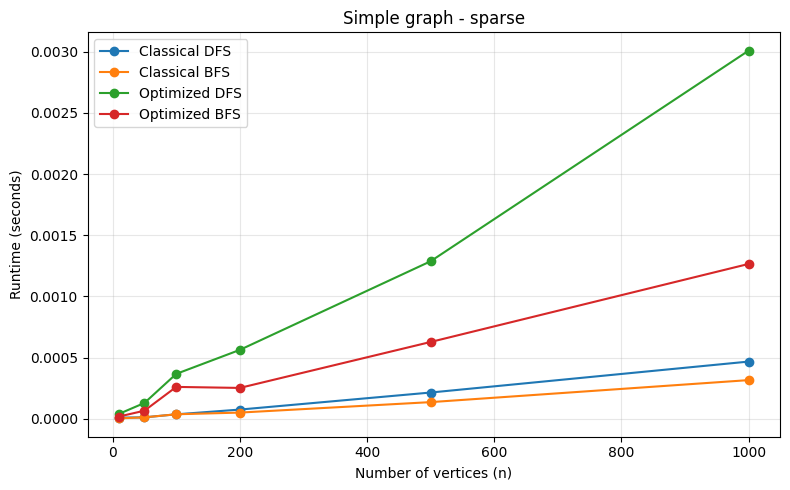

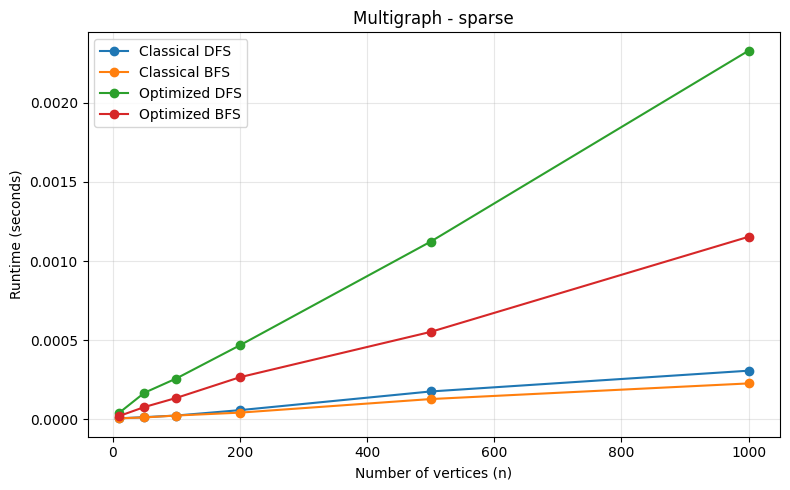

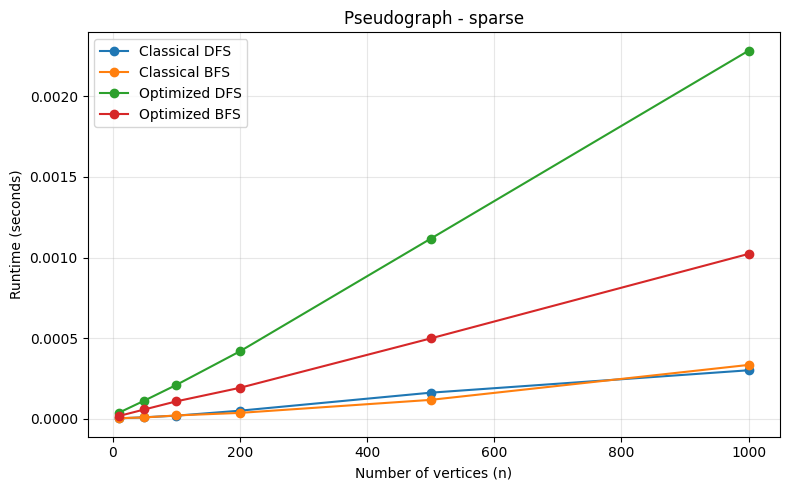

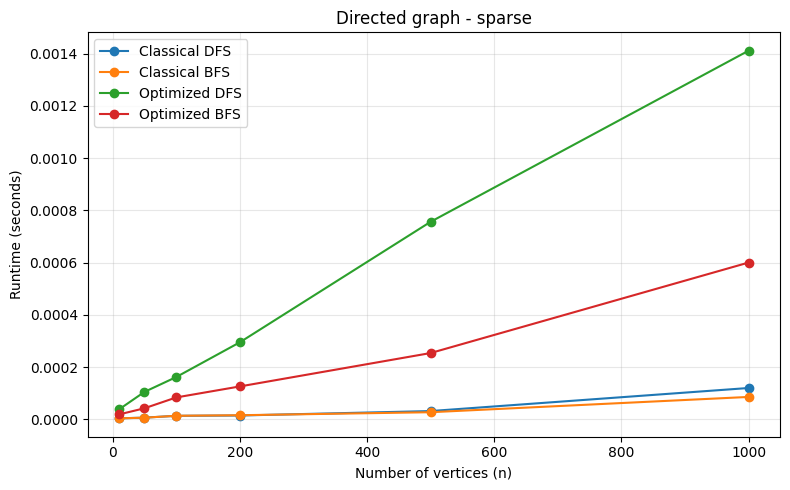

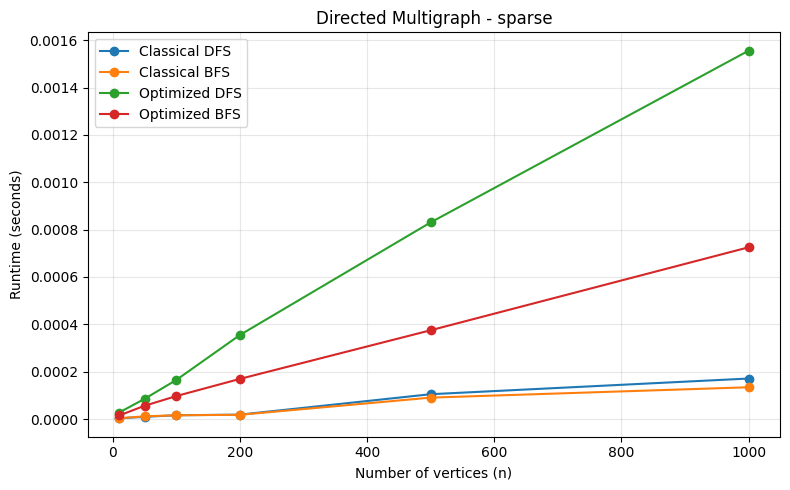

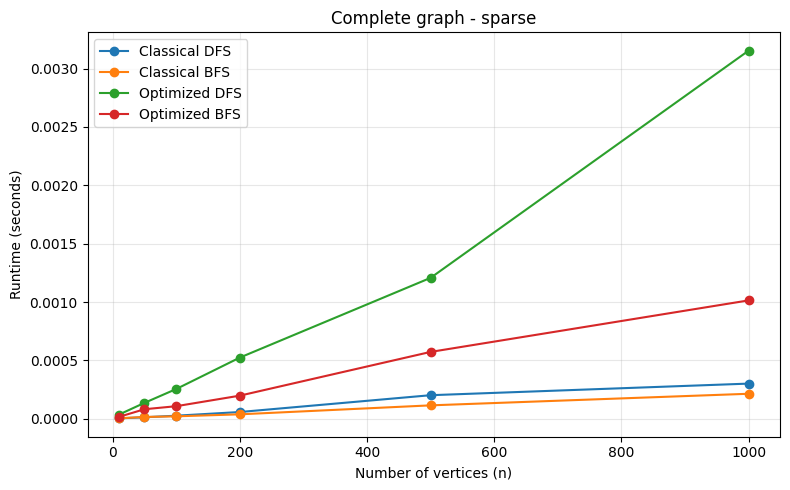

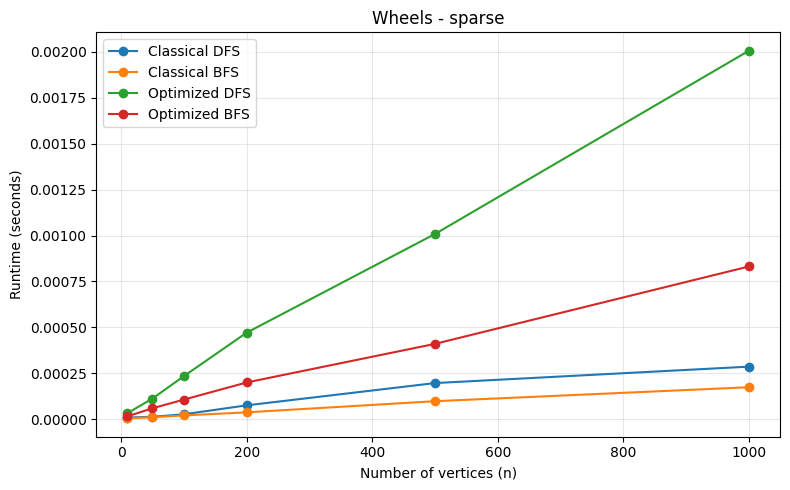

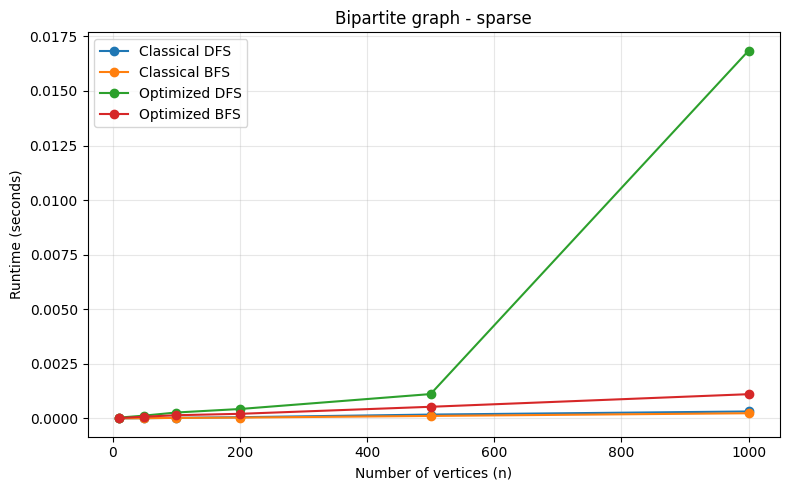

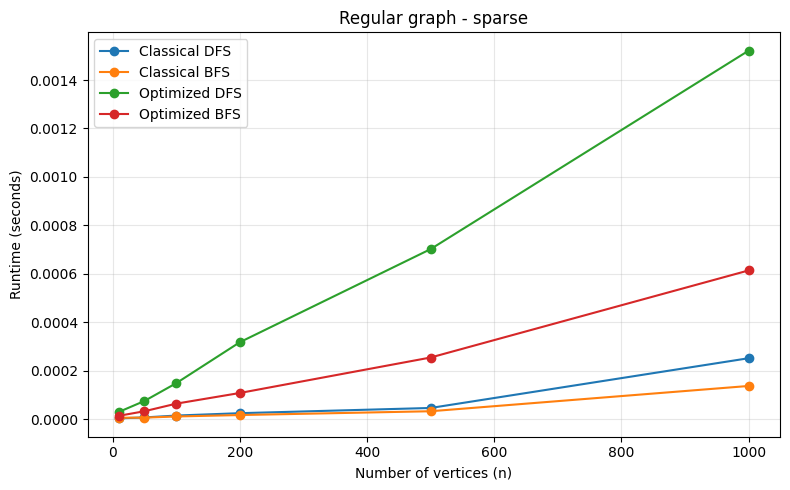

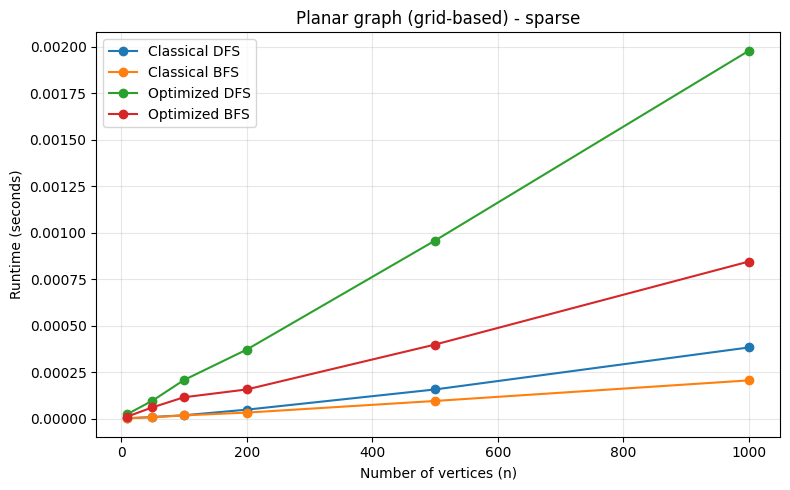

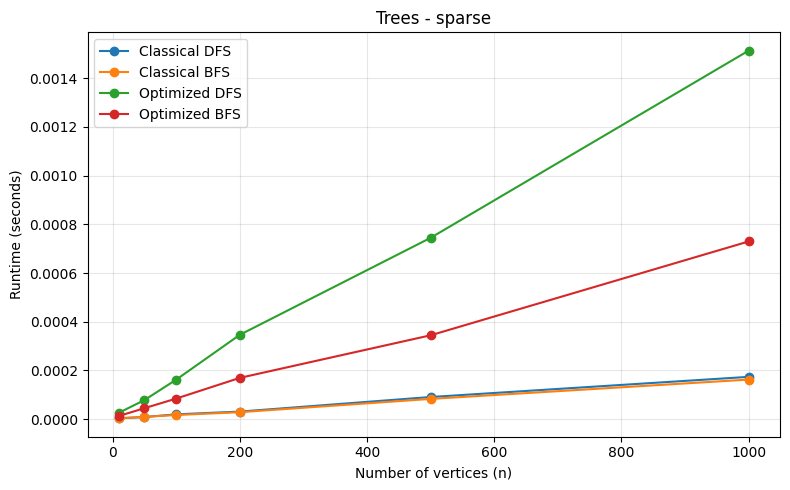

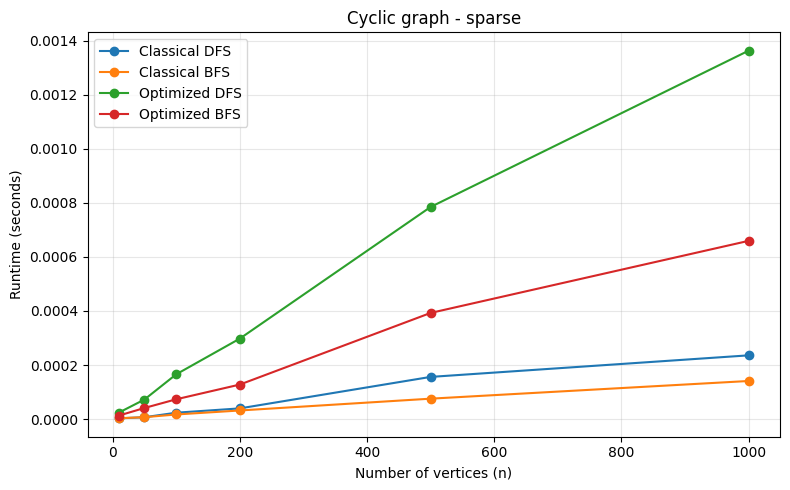

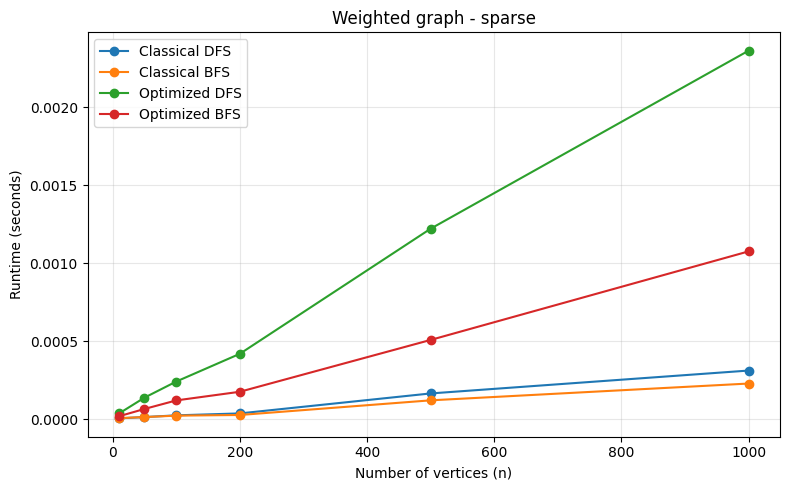

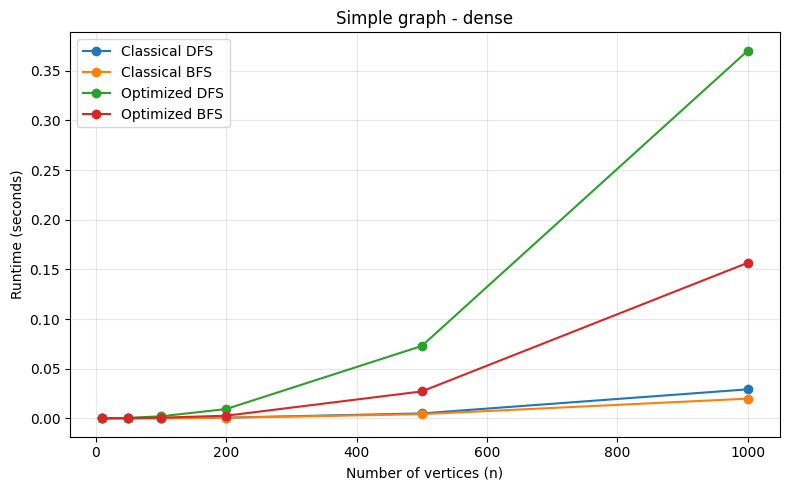

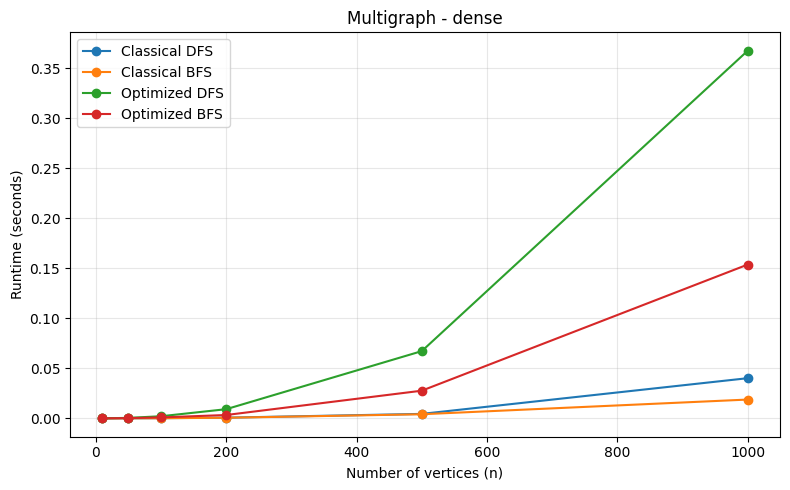

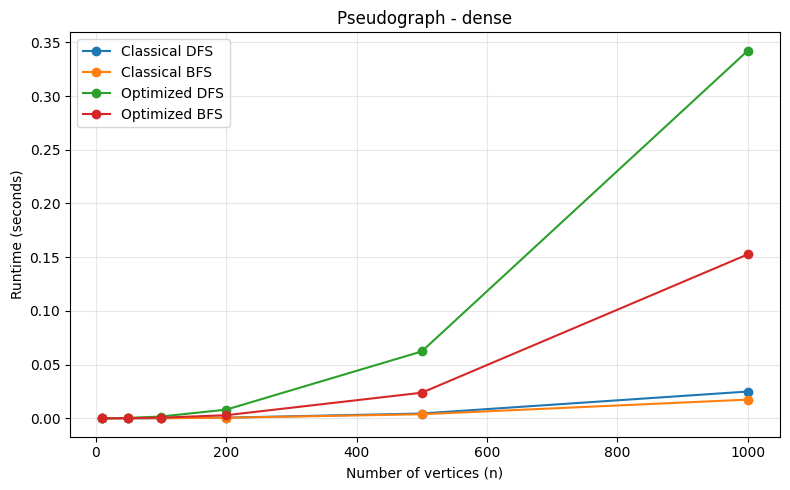

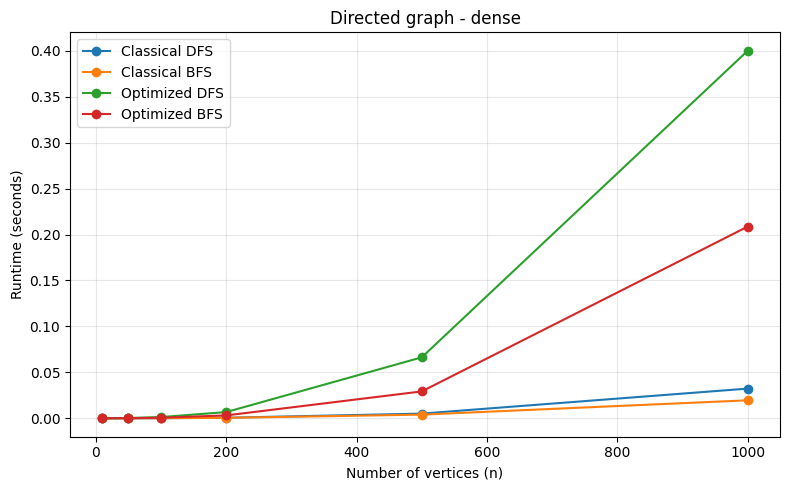

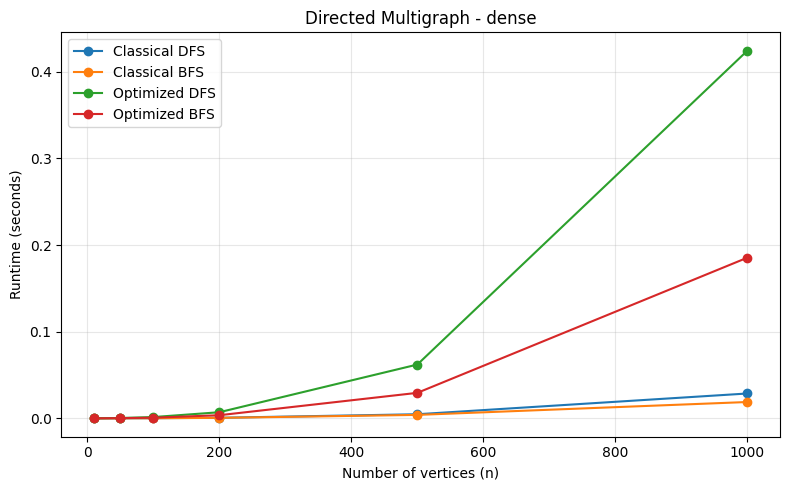

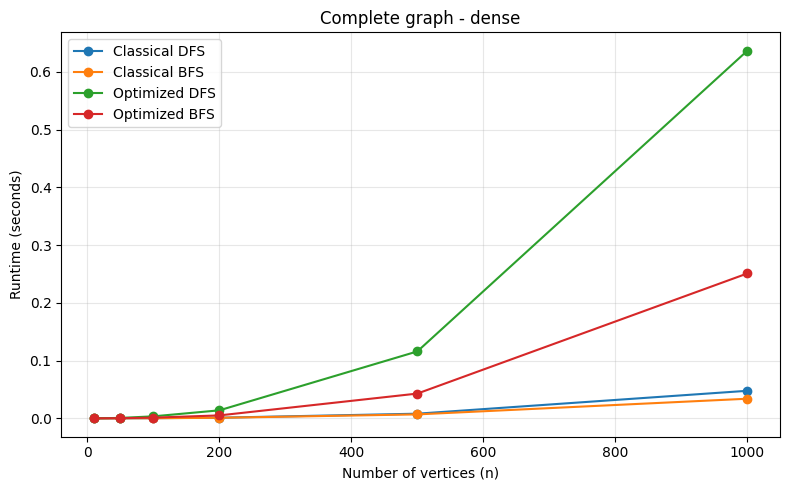

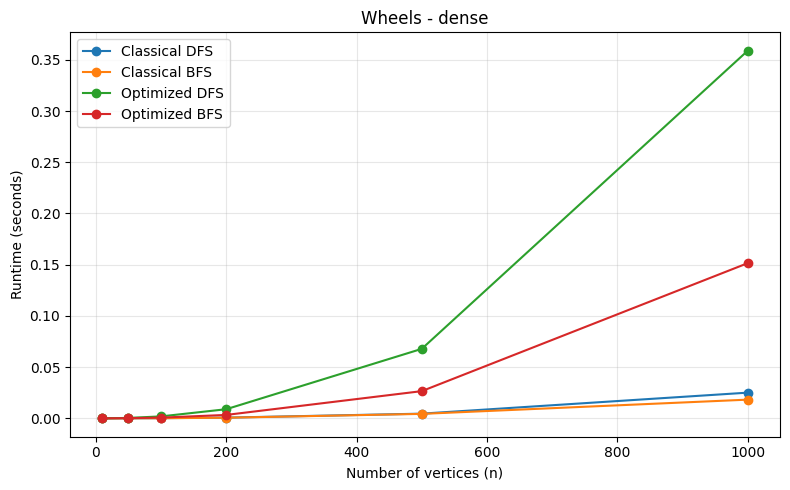

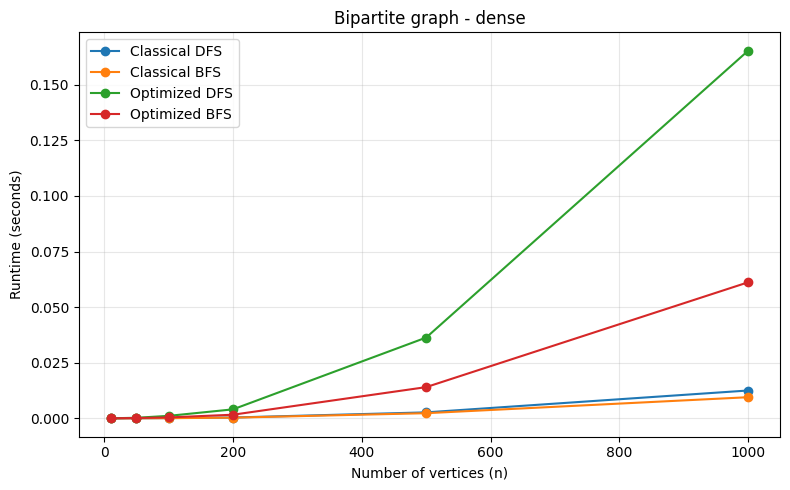

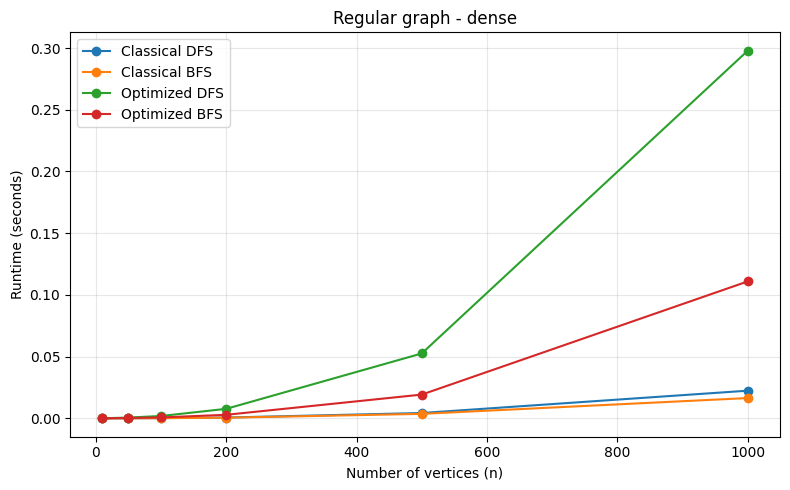

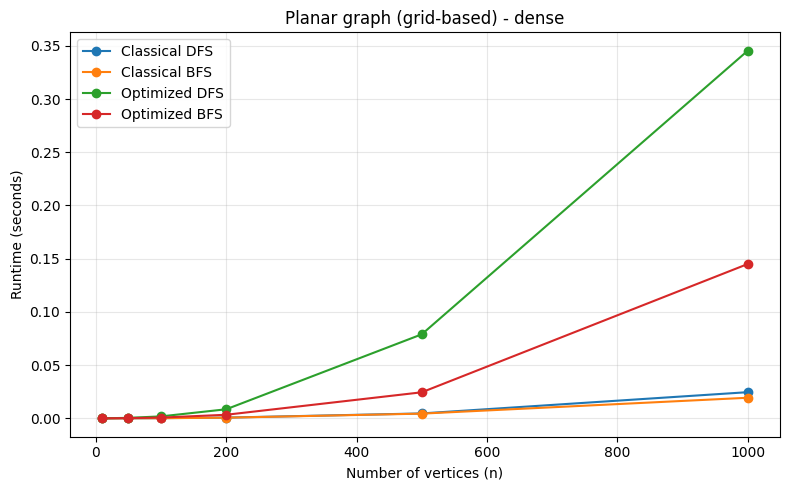

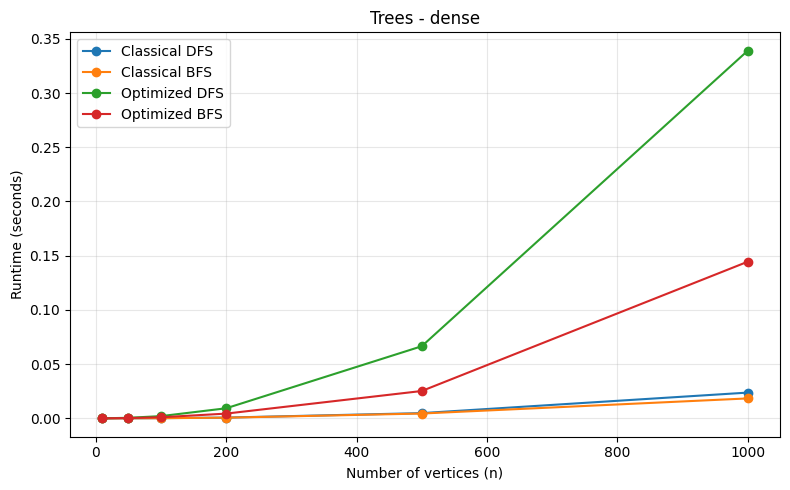

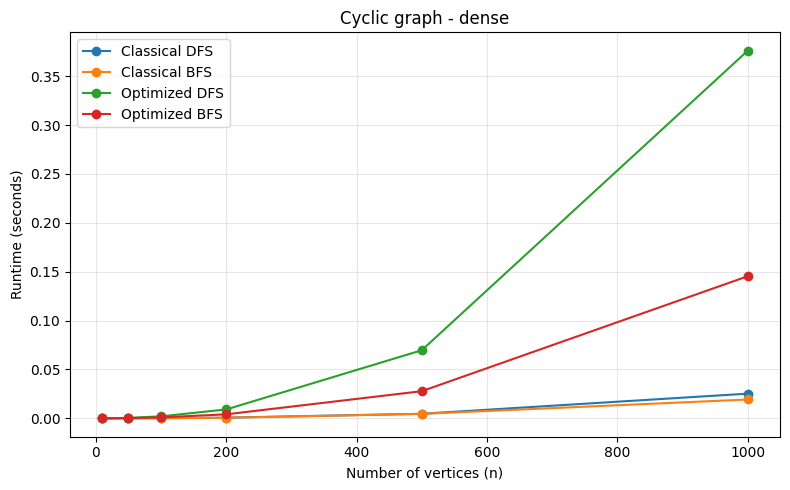

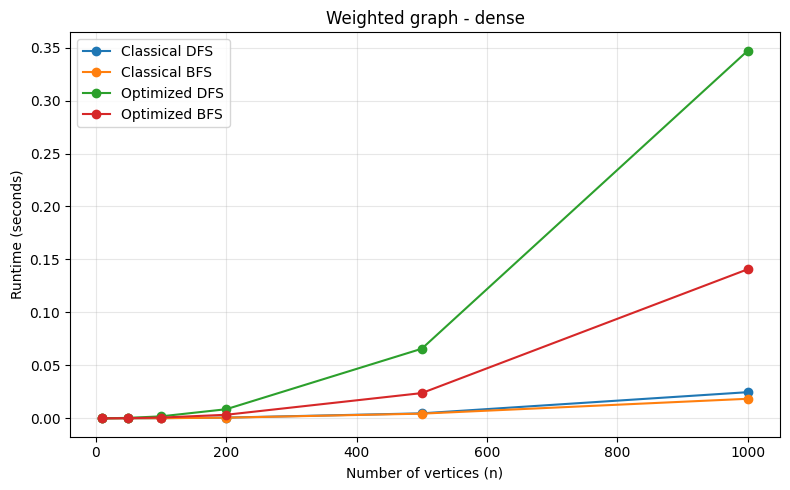

In [28]:
# Plot results

def plot_results(results: Dict[Tuple[str, str], Dict[int, Dict[str, float]]], density: str) -> None:
    algo_labels = {
        "classical_dfs": "Classical DFS",
        "classical_bfs": "Classical BFS",
        "optimized_dfs": "Optimized DFS",
        "optimized_bfs": "Optimized BFS",
    }
    for graph_type in GRAPH_TYPES:
        key = (graph_type, density)
        if key not in results:
            continue
        data = results[key]
        sizes = sorted(data.keys())
        plt.figure(figsize=(8, 5))
        for algo, label in algo_labels.items():
            ys = [data[n][algo] for n in sizes]
            plt.plot(sizes, ys, marker="o", label=label)
        plt.title(f"{graph_type} - {density}")
        plt.xlabel("Number of vertices (n)")
        plt.ylabel("Runtime (seconds)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_results(results, "sparse")
plot_results(results, "dense")

# Conclusion (fill after running)

- Summarize how runtime scales with n for each algorithm across graph families.
- Note differences between sparse and dense cases.
- Identify which algorithm is fastest in most cases and where it changes.